# Data worth, for nearly free

_Which analyte is worth paying the lab for?_

Back in [`part1_03_obs_weights_and_truth`](../part1_03_obs_weights_and_truth/dizon_obs_weights_and_truth.ipynb) we conditioned the history match on five species &mdash; SO₄, O₂, NO₃, pH and temperature (`so4`, `o0`, `no3`, `ph`, `tmp`) &mdash; and **deliberately held back the major cations** (Ca, Na, Fe). We made a promise there: we would come back and ask whether measuring those cations would actually have *helped*. This is where we keep it.

The question is not academic. Field chemistry costs money. Every analyte you add to the sampling schedule is more lab time, more boreholes sampled more often, more budget. A modeller is constantly asked, in one form or another: **is this measurement worth it?** &mdash; will spending on it actually sharpen the decision, or just add numbers to a spreadsheet the forecast never feels.

"Data worth" is the formal name for that question, and the answer is decision-first: a measurement is worth something *only if it would have narrowed the thing we are deciding on*. Here that thing is the canonical forecast &mdash; peak SO₄ at the supply well (`wellopt`) over the supply period, whose distribution sets the treatment capacity the operator designs to its P95. A new measurement is worth paying for if, and only if, adding it to the history match would have tightened the posterior forecast distribution: less spread, a lower P95, less treatment capacity bought against uncertainty we could have resolved for the price of a lab analysis.

Where this notebook sits in the sequence:

- [`../part1_05_dsi_basics/dizon_dsi_basics.ipynb`](../part1_05_dsi_basics/dizon_dsi_basics.ipynb) trained the DSI emulator on the prior Monte Carlo and conditioned it on the five conditioning species &mdash; that is the *baseline* history match we measure everything against here.
- [`../part1_06_full_model_check/`](../part1_06_full_model_check/) validated that DSI posterior against the full model.
- [`../part1_03_obs_weights_and_truth/`](../part1_03_obs_weights_and_truth/dizon_obs_weights_and_truth.ipynb) is where the held-back cations were set aside and the synthetic truth was chosen.
- [`../part1_08_optimization/`](../part1_08_optimization/) uses the same emulator to value held-back *decisions*; this notebook values held-back *data*.

> The one thing this notebook will **never** do is run the full model. Every number it produces comes from re-fitting and re-conditioning the DSI emulator on different slices of observations the prior ensemble *already produced*. That is the whole point &mdash; see [why emulation makes this cheap](#Why-emulation-makes-this-cheap), below.

### Admin

We lean on the vendored dependency trees (`flopy`, `pyemu`) that ship with this repository; the asserts below fail loudly if a different `pyemu` is on the path. `herebedragons` (imported as `hbd`) holds the shared plotting and bookkeeping helpers, and every workspace this notebook creates lives *inside this notebook's own directory*.

In [1]:
import os
import sys
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

import flopy
import pyemu
from pyemu.emulators import DSI

warnings.filterwarnings("ignore")

sys.path.insert(0, "..")
import herebedragons as hbd

Confirm we are running the vendored dependencies and not something else `pip` dragged in:

In [2]:
assert "dependencies" in flopy.__file__, flopy.__file__
assert "dependencies" in pyemu.__file__, pyemu.__file__

**Prerequisite check.** Everything here is built on the prior Monte Carlo observation ensemble from upstream &mdash; the same ensemble [`part1_05`](../part1_05_dsi_basics/dizon_dsi_basics.ipynb) trained DSI on. We resolve it in the canonical order the whole series uses: the tracked, thinned `prebaked/prior_mc_obs_ensemble.jcb` artifact first (it ships its companion control file `prebaked/pest.pst`), then a full prior MC you ran into the repo-root `master_priormc`. If neither is found, stop and run the prior MC notebook first.

Note we do *not* read `part1_05`'s conditioned `dsi_template/`. This notebook re-fits DSI from the prior ensemble for **every** arm &mdash; because the headline arm (the cations) trains the emulator on *extra* observation columns the baseline emulator never carried, so a single shared template would not do. Re-fitting from the prior is cheap and keeps each arm strictly comparable.

In [3]:
# resolve the prior MC source in the canonical order used across the series:
#   1. the tracked, thinned prebaked obs ensemble (../../prebaked/prior_mc_obs_ensemble.jcb)
#   2. a full prior MC run into the repo-root master dir (../../master_priormc)
prebaked_oe = Path("..") / ".." / "prebaked" / "prior_mc_obs_ensemble.jcb"
pmc_d = Path("..") / ".." / "master_priormc"

if prebaked_oe.exists() and (prebaked_oe.parent / "pest.pst").exists():
    pmc_d = prebaked_oe.parent
    pst = pyemu.Pst(str(pmc_d / "pest.pst"))
    prior_oe_path = prebaked_oe          # named artifact; loaded with from_binary below
    print(f"loaded prebaked prior MC control file from {pmc_d}")
elif (pmc_d / "pest.pst").exists():
    pst = pyemu.Pst(str(pmc_d / "pest.pst"))
    prior_oe_path = None                 # a live master dir; use the pst.ies.obsen accessor
    print(f"loaded prior MC control file from {pmc_d}")
else:
    raise Exception(
        "you need to run the '../part1_04_prior_mc/dizon_prior_mc.ipynb' notebook first "
        "-- it produces the prior Monte Carlo ensemble this notebook re-slices "
        f"(looked for the prebaked artifact '{prebaked_oe}' and the master dir '{pmc_d}')")

loaded prebaked prior MC control file from ../../prebaked


Physical core count, used only to set the emulator's internal IES thread count. Each arm is a single, cheap PESTPP-IES conditioning *of the emulator* &mdash; we run them one after another rather than farm them out, because each finishes in well under a minute.

In [4]:
num_threads = psutil.cpu_count(logical=False)
num_threads

16

## What data worth means here

The classic data-worth experiment compares two history matches that differ only in their observations, and reads the difference *in the forecast*. There are two directions:

- **Adding** observations and watching the forecast uncertainty shrink &mdash; "what would this extra data buy us?"
- **Removing** observations and watching it grow &mdash; "how much is the data we already collect actually doing?"

Both reduce to the same operation: re-condition on a different observation set and compare the posterior forecast spread. The headline here is the *adding* kind &mdash; the held-back cations &mdash; but we run a removing arm too (condition on SO₄ alone, and on a shorter monitoring window), because that answers the budget question from the other side: if a measurement could be cut without the forecast noticing, you are paying for it for nothing.

The metric is the posterior **forecast** distribution &mdash; *not* how well each subset fits its own observations. A subset that fits beautifully but leaves the supply-well sulfate forecast just as wide as the prior has bought us nothing we can decide on. So for every arm we summarise the same single number: the spread of peak SO₄ at the supply well over the supply period (the 5th&ndash;95th percentile range), and where its P95 sits. A *narrower* posterior &mdash; and especially a lower P95, the number treatment capacity is designed to &mdash; is the worth.

## Why emulation makes this cheap

Done the conventional way, data worth is brutally expensive. To value one candidate observation set you would re-run the whole history match against the full model &mdash; a fresh PESTPP-IES ensemble, hundreds of ~6 min/run DIZON evaluations, *per arm*. With a handful of arms that is days of compute to answer a question that is, in the end, advisory: it tells you what to go and measure, it does not change the model.

That cost is exactly why conventional data-worth analysis is so often skipped on reactive-transport models, and exactly the gap emulation closes.

Here is the trick. The prior Monte Carlo already ran the full model once for every realisation, and recorded **all** the outputs &mdash; every species at every site at every time, the held-back cations included. So:

- Choosing a different observation subset to condition on is just choosing **different columns** of an ensemble that already exists. No new forward runs.
- Re-fitting DSI on those columns and re-conditioning with PESTPP-IES runs in **seconds to minutes on the emulator**, not days on the model.

The data we "held back" was never actually un-simulated &mdash; the prior MC computed the cations for free, as a side effect of running the model at all. Emulation lets us cash that in. **This is the dividend:** the expensive ensemble was paid for once, upstream, and data worth falls out of it for nearly nothing.

One honest caveat, stated up front so it does not get lost. We are valuing the cations *against the synthetic truth* &mdash; the cation "measurements" we condition on are this truth realisation's own cation values, perturbed by the noise model. So this experiment answers "would these measurements have helped *in this synthetic world*?", which is the right question for teaching the method and a fair guide for the real campaign &mdash; but it is not a promise about the field, where structural error muddies what any measurement can constrain. The [real-data capstone](../part1_09_real_data_capstone/) is where that distinction comes home.

## Load the prior ensemble and pin down the forecast

Everything starts from the prior observation ensemble. For DSI we subsample the dense time series to the model's stress-period boundary times &mdash; the same step [`part1_05`](../part1_05_dsi_basics/dizon_dsi_basics.ipynb) took, and for the same reason: it keeps the breakthrough shape while keeping the emulator's output dimension manageable. Read the boundary times from the flow model's `tdis` if `part1_01`'s workspace is on disk, otherwise derive them from the control file's obs metadata:

In [5]:
gwf_ws = Path("..", "part1_01_build_model", "model")
if (gwf_ws / "mfsim.nam").exists():
    sim = flopy.mf6.MFSimulation.load(sim_ws=str(gwf_ws), load_only=["tdis"],
                                      verbosity_level=0)
    perioddata = pd.DataFrame(sim.tdis.perioddata.get_data())
    modeltimes = perioddata.perlen.cumsum().values
else:
    od = pst.observation_data
    cond = od.loc[(od.weight > 0) & (pd.to_numeric(od.time, errors="coerce") > 0)]
    modeltimes = np.array(sorted(pd.to_numeric(cond.time, errors="coerce").dropna().unique()))
print(f"{len(modeltimes)} stress-period boundary times, day "
      f"{modeltimes.min():.0f} to {modeltimes.max():.0f}")

35 stress-period boundary times, day 2 to 728


Re-parse the immutable obsname tokens (`part1_02` overwrites the `oname` column for convenience), select the concentration time-series observations at the boundary times, and load the prior observation ensemble. These are the columns DSI can learn from &mdash; **and the prebaked ensemble now carries the held-back cations among them**, recorded at the same fortnightly stride the field campaign would sample. We confirm that below; it is the fact that makes the whole notebook possible.

In [6]:
pst.try_parse_name_metadata()
obs = pst.observation_data.copy()
obs["time"] = pd.to_numeric(obs["time"], errors="coerce")

# the time-series concentration obs live in the 'conc' observation type; select by
# oname (the immutable token), not obgnme, which part1_02/03 retag
conc = obs.loc[obs.oname == "conc"].copy()
conc["time"] = pd.to_numeric(conc["time"], errors="coerce")
keepobs = conc.loc[conc.time.isin(modeltimes)].obsnme.tolist()

# the prior obs ensemble (iteration 0 of the prior MC = the prior)
if prior_oe_path is not None:
    oe = pyemu.ObservationEnsemble.from_binary(pst=pst, filename=str(prior_oe_path))
else:
    oe = pst.ies.obsen
oe = oe._df if hasattr(oe, "_df") else pd.DataFrame(oe)
data_all = oe.loc[:, keepobs].copy()
print(f"prior obs ensemble: {data_all.shape[0]} realisations x {data_all.shape[1]} obs at boundary times")

prior obs ensemble: 195 realisations x 2851 obs at boundary times


Now confirm the held-back cations really are in the ensemble. The prior MC recorded them all along; the prebaked artifact was regenerated to keep them at a fortnightly stride over the history period. We read that straight off the control file's observation metadata &mdash; no model run &mdash; and list the conditioning species and the cations the model actually simulates (it carries `ca`, `na`, `fe`, `fe2`; the conceptual list also names Mg and K, which this model does not simulate, so we filter to what exists and never invent an observation):

In [7]:
COND_SPECIES = ["so4", "o0", "no3", "ph", "tmp"]   # the baseline five (o0 = dissolved O2)
HELD_BACK_CATS = ["ca", "mg", "na", "k", "fe", "fe2"]  # conceptual cation list

present = set(conc.loc[conc.time.isin(modeltimes)].variable.unique())
cond_present = [s for s in COND_SPECIES if s in present]
cats_present = [s for s in HELD_BACK_CATS if s in present]
print("conditioning species present:", cond_present)
print("held-back cations present   :", cats_present, "(mg, k not simulated by this model)")

# how many history-window cation obs the prebaked ensemble carries, and at what stride
cat_hist = conc.loc[conc.variable.isin(cats_present) & conc.time.isin(modeltimes) & (conc.time <= 252)]
cat_times = sorted(cat_hist.time.dropna().unique())
print(f"\ncation history obs at boundary times: {len(cat_hist)} obs across {len(cat_times)} times")
print(f"cation sample days (history window): {[int(t) for t in cat_times]}")

conditioning species present: ['so4', 'o0', 'no3', 'ph', 'tmp']
held-back cations present   : ['ca', 'na', 'fe', 'fe2'] (mg, k not simulated by this model)

cation history obs at boundary times: 1056 obs across 12 times
cation sample days (history window): [14, 28, 42, 56, 70, 98, 112, 126, 140, 196, 224, 252]


Define the forecast once and reuse it for every arm &mdash; peak SO₄ at the supply well over the supply period, the same definition `part1_05` used. Concentrations are carried in **mol/L**, so we convert to mg/L (SO₄ molar mass 96.06 g/mol). The forecast spans all three supply-well screens (`welopt-ly1`, `welopt-ly3`, `welopt-ly5`); "peak" is the maximum over those screens and over the supply period (308&ndash;728 d), taken per realisation, so the forecast is a *distribution* across the ensemble.

In [8]:
SO4_MW = 96.06   # g/mol
FORECAST_SCREENS = ["welopt-ly1", "welopt-ly3", "welopt-ly5"]
SUPPLY_START, SUPPLY_END = 308.0, 728.0

def peak_so4_mgl(ensemble, screens=FORECAST_SCREENS):
    """Peak supply-period SO4 (mg/L), max over all supply-well screens, per realisation."""
    fc = conc.loc[conc.obsid.isin(screens) & (conc.variable == "so4")
                  & (conc.time >= SUPPLY_START) & (conc.time <= SUPPLY_END)]
    cols = [c for c in fc.obsnme if c in ensemble.columns]
    return ensemble.loc[:, cols].max(axis=1) * 1000.0 * SO4_MW   # mol/L -> mg/L

# the forecast columns must be in every arm's training set, so the emulator can predict them
forecast_cols = [c for c in conc.loc[conc.obsid.isin(FORECAST_SCREENS)
                 & (conc.variable == "so4") & (conc.time >= SUPPLY_START)
                 & (conc.time <= SUPPLY_END)].obsnme if c in data_all.columns]

prior_peak = peak_so4_mgl(oe)
print(f"prior peak SO4 at supply well (mg/L): median={prior_peak.median():.1f}  "
      f"P5={prior_peak.quantile(0.05):.1f}  P95={prior_peak.quantile(0.95):.1f}")

prior peak SO4 at supply well (mg/L): median=81.9  P5=71.7  P95=94.4


## The synthetic truth (picked here, not loaded)

The cation "measurements" we condition on are the synthetic truth realisation's own cation values. So we need the truth &mdash; and, exactly as [`part1_05`](../part1_05_dsi_basics/dizon_dsi_basics.ipynb) does, we **re-apply the part1_03 selection criterion** rather than read a truth file: the realisation whose peak supply-well SO₄ is nearest the prior 87.5th percentile (the middle of the upper quartile), so the prior median under-predicts it and conditioning has something visible to correct toward. Identical constant, identical pick &mdash; realisation `101`.

In [9]:
TRUTH_PCTILE = 0.875   # same constant as part1_03 and part1_05
target = prior_peak.quantile(TRUTH_PCTILE)
truth_real = (prior_peak - target).abs().idxmin()
truth_fc = float(prior_peak.loc[truth_real])
print(f"synthetic truth = realisation '{truth_real}', peak SO4 = {truth_fc:.1f} mg/L "
      f"(prior median {prior_peak.median():.1f} mg/L under-predicts it)")

synthetic truth = realisation '101', peak SO4 = 90.8 mg/L (prior median 81.9 mg/L under-predicts it)


## The recipe: one emulator re-fit per arm

Every arm is the same workflow, differing only in **which observations the emulator trains on and which carry weight when PESTPP-IES conditions it**:

1. **Choose the training columns and the conditioning set.** A list of species (and a monitoring window). The training columns are those species at the boundary times *plus the forecast columns* (the emulator must always be able to predict the forecast). The conditioning set is the history-window observations that get non-zero weight.
2. **Re-fit DSI** on those columns with the proven transform (`normal_score`, quadratic extrapolation, `energy_threshold=0.975`), hold out the truth and a validation set, and **measure the emulator's per-obs error** on the held-out realisations &mdash; that error joins the noise budget.
3. **Condition the emulator** with PESTPP-IES in run-storage mode (`/e`), against the synthetic truth's own values plus a species-specific noise ensemble.
4. **Read the forecast spread** with `peak_so4_mgl` and compare back to the baseline.

All of that lives in one helper so each arm is a single call. The numerical care in it &mdash; the guarded `encode`, the emulator-error inflation, the within-series correlated noise and √n weight deflation, the dropped phi-factor and multimodal options &mdash; is cribbed verbatim from [`part1_05`](../part1_05_dsi_basics/dizon_dsi_basics.ipynb), which earned every line of it the hard way. We do not reinvent it; we reuse it.

First the noise tables, shared by every arm so the comparison is clean. Concentrations get a 7% proportional standard deviation with a per-species floor; pH and temperature get absolute standard deviations (temperature's 0.5 °C is in the **stored** units &mdash; Tmp is carried ×1e-3 in this model, the scaling convention that bit us in `part1_05`). The held-back cations follow the same shape as the other concentrations: 7% proportional, with a 5e-5 mol/L floor.

In [10]:
CONC_PROP = 0.07                 # 7% proportional for concentration species
CONC_FLOOR_MOLL = {              # per-species absolute floor on the conc sigma (mol/L)
    "so4": 5.0e-5, "o0": 2.0e-5, "no3": 2.0e-5,
}
CAT_PROP  = 0.07                 # cations: same 7% proportional ...
CAT_FLOOR = 5.0e-5               # ... with a 5e-5 mol/L floor (mol/L)
PH_ABS  = 0.1                    # absolute, pH units
TMP_ABS = 0.5 * 1e-3             # absolute, 0.5 degC -- in STORED units (Tmp carried x1e-3)

CATIONS = cats_present           # ['ca', 'na', 'fe', 'fe2']

The guarded `encode` &mdash; **required**, not optional. A naive least-squares projection of a realisation that lies even slightly outside the training subspace returns latent coordinates with enormous norms, and the normal-score back-transform then extrapolates them into absurdity (`part1_05` saw 1e16 mol/L before these two guards). So we clip into the training range and project with a rank-revealing pseudo-inverse:

In [11]:
def encode(dsi, df):
    """Project realisations (obs-space rows) onto DSI latent coordinates. Two guards
    (clip-to-training-range + pinv) keep the normal-score back-transform from exploding."""
    xt = dsi.transformer_pipeline.transform(df.copy())
    xt = xt.loc[:, dsi.ovals.index]
    lo = dsi.data_transformed[dsi.ovals.index].min(axis=0)
    hi = dsi.data_transformed[dsi.ovals.index].max(axis=0)
    xt = xt.clip(lower=lo, upper=hi, axis=1)
    dev = xt.values - dsi.ovals.values[np.newaxis, :]
    pinv = np.linalg.pinv(dsi.pmat, rcond=1e-8)
    pvals = pinv @ dev.T
    return pd.DataFrame(pvals.T, index=df.index,
                        columns=[f"p_{i}" for i in range(dsi.pmat.shape[1])])

And the arm helper itself. It builds the training columns, fits and validates DSI, sets the conditioning targets and the correlated noise ensemble, runs PESTPP-IES against the emulator in its own subdirectory (`dw_<name>/`, gitignored), and returns the posterior peak-SO₄ distribution. Each call is one arm:

In [12]:
def species_cols(species):
    """Training columns for a species set: conc obs at boundary times for those species."""
    c = conc.loc[conc.variable.isin(species) & conc.time.isin(modeltimes)]
    return [x for x in c.obsnme if x in data_all.columns]


def run_arm(name, train_species, cond_species, t_end=252.0, n_reals=500, seed=20260606):
    """Re-fit DSI on the train_species columns (+ forecast) and condition on the
    history-window obs (time <= t_end) of cond_species. Returns posterior peak SO4 (mg/L).
    No full-model runs: this conditions the *emulator* in runstore mode."""
    # 1. training columns = chosen species at boundary times, plus the forecast columns
    train_cols = sorted(set(species_cols(train_species)) | set(forecast_cols))
    data = data_all.loc[:, train_cols].copy()

    # drop the truth from training; hold out a validation set for the emulator-error measure
    truth = data.loc[[truth_real]].copy()
    truth[truth.abs() < 1e-8] = 0.0
    d = data.drop(index=truth.index)
    rng = np.random.default_rng(0)
    val_reals = rng.choice(d.index.values, size=min(20, d.shape[0] // 5), replace=False)
    validation = d.loc[val_reals].copy()
    train = d.drop(index=val_reals).copy()

    # 2. fit DSI (proven transform + energy threshold) and measure its per-obs error
    transforms = [{"type": "normal_score", "quadratic_extrapolation": True}]
    dsi = DSI(data=train, transforms=transforms, energy_threshold=0.975)
    dsi.fit()
    val_pred = dsi.predict(encode(dsi, validation))
    emu_rmse = ((val_pred[validation.columns] - validation) ** 2).mean(axis=0) ** 0.5

    # 3. prepare the runstore PEST++ interface in this arm's own (gitignored) dir
    dtd = Path(f"dw_{name}")
    if dtd.exists():
        shutil.rmtree(dtd)
    dpst = dsi.prepare_pestpp(dtd, use_runstor=True)
    dobs = dpst.observation_data
    dobs["time"] = pd.to_numeric(dobs["time"], errors="coerce")

    # the synthetic truth becomes the conditioning target; weight only the chosen
    # species' history-window obs (nothing after the decision date informs the match)
    dobs.loc[truth.columns, "obsval"] = truth.values[0]
    dobs["weight"] = 0.0
    nz = dobs.loc[dobs.variable.isin(cond_species) & (dobs.time > 0) & (dobs.time <= t_end)
                  & (dobs.obsval < 1e30)].index

    # species-specific sigma (cations share the conc shape); fold in the emulator error
    var = dobs.loc[nz, "variable"]
    val = dobs.loc[nz, "obsval"].astype(float)
    std = pd.Series(0.0, index=nz)
    is_ph, is_tmp = var == "ph", var == "tmp"
    is_cat = var.isin(CATIONS)
    is_conc = ~(is_ph | is_tmp | is_cat)
    floor = var[is_conc].map(CONC_FLOOR_MOLL).fillna(0.0).astype(float)
    std[is_conc] = np.maximum(val[is_conc].abs() * CONC_PROP, floor)
    std[is_cat]  = np.maximum(val[is_cat].abs() * CAT_PROP, CAT_FLOOR)
    std[is_ph]   = PH_ABS
    std[is_tmp]  = TMP_ABS
    sigma_emu = emu_rmse.reindex(nz).fillna(0.0)
    std_total = np.sqrt(std ** 2 + sigma_emu ** 2)

    # correlated-within-series noise => deflate each series' weight by sqrt(n) so the
    # smoother does not count ~n samples of one biased series as ~n independent facts
    series = dobs.loc[nz, "obsid"].astype(str) + ":" + dobs.loc[nz, "variable"].astype(str)
    n_per_series = series.map(series.value_counts())
    std_total = std_total * np.sqrt(n_per_series.astype(float))
    dobs.loc[nz, "standard_deviation"] = std_total
    dobs.loc[nz, "weight"] = 1.0 / std_total
    dobs["obgnme"] = dobs.obsid.astype(str) + ":" + dobs.variable.astype(str)

    # weighting philosophy is the species sigma table + emulator error, nothing else
    dpst.pestpp_options.pop("ies_phi_factor_file", None)
    dpst.pestpp_options.pop("ies_multimodal_alpha", None)   # dropped, per part1_05
    dpst.pestpp_options["ies_num_reals"] = n_reals
    dpst.pestpp_options["save_binary"] = True
    dpst.pestpp_options["ies_num_threads"] = num_threads
    dpst.control_data.noptmax = 3

    # 4. observation noise ensemble: truth + correlated draw within each site:species
    noise = pyemu.ObservationEnsemble.from_gaussian_draw(dpst, num_reals=n_reals)
    nzobs = dobs.loc[nz].copy()
    rng2 = np.random.default_rng(seed)
    for grp in nzobs.obgnme.unique():
        g = nzobs.loc[nzobs.obgnme == grp]
        z = rng2.standard_normal(noise.shape[0])
        noise.loc[:, g.index] = (g.obsval.values[None, :]
                                 + z[:, None] * g.standard_deviation.values[None, :])
    zero_obs = nzobs.loc[nzobs.obsval == 0].index           # pre-breakthrough zeros stay zero
    noise.loc[:, zero_obs] = 0.0
    noise._df = noise._df.dropna(axis=1)
    noise.to_binary(str(dtd / "noise.jcb"))
    dpst.write(str(dtd / "dsi.pst"), version=2)

    # run PESTPP-IES against the emulator in runstore mode (the /e switch is mandatory)
    hbd.get_bins(str(dtd))
    pyemu.os_utils.run("pestpp-ies dsi.pst /e", cwd=str(dtd))

    # 5. read the posterior forecast (last iteration on disk)
    rpst = pyemu.Pst(str(dtd / "dsi.pst"))
    obsen = rpst.ies.obsen
    last_it = max(i for i in range(dpst.control_data.noptmax + 1)
                  if (dtd / f"dsi.{i}.obs.jcb").exists())
    pk = peak_so4_mgl(obsen.loc[last_it].copy())
    print(f"[{name}] {len(nz)} conditioning obs | latent dim {dsi.latent_dim} | "
          f"posterior peak SO4 median={pk.median():.1f} P95={pk.quantile(0.95):.1f} mg/L")
    return pk

## The arms we compare

Four arms, each a different answer to "what is the data worth?":

1. **baseline** &mdash; the canonical conditioning set (the five species over the full history window). This should reproduce `part1_05`'s posterior.
2. **+ cations** &mdash; the headline: add the held-back cations (`ca`, `na`, `fe`, `fe2`). Their conditioning values are the synthetic truth's own cation breakthrough, perturbed by the noise model. *Does the supply-well sulfate forecast tighten?*
3. **so4-only** &mdash; condition on the sulfate series alone. The mirror question: how much of the baseline's worth comes from the oxidant/buffer/heat signals rather than sulfate itself?
4. **short monitoring** &mdash; the canonical species, but only the first ~180 days of monitoring. We cannot extend past the decision date (252 d), but we *can* ask what the back half of the history window adds by cutting it.

Each call re-fits the emulator and conditions it &mdash; cheap, no full-model runs &mdash; and prints its posterior as it goes:

In [13]:
results = {}
results["baseline"]         = run_arm("baseline", COND_SPECIES,            COND_SPECIES)
results["+ cations"]        = run_arm("cations",  COND_SPECIES + CATIONS,  COND_SPECIES + CATIONS)
results["so4-only"]         = run_arm("so4only",  ["so4"],                 ["so4"])
results["short monitoring"] = run_arm("short",    COND_SPECIES,            COND_SPECIES, t_end=180.0)

noptmax:0, npar_adj:116, nnz_obs:0
noptmax:3, npar_adj:116, nnz_obs:1750
./pestpp-ies dsi.pst /e




             pestpp-ies: a GLM iterative ensemble smoother

                   by the PEST++ development team

...processing command line: ' ./pestpp-ies dsi.pst /e'
...using external run manager


version: 5.2.24
binary compiled on Nov 12 2025 at 11:54:09

using control file: "dsi.pst"
in directory: "/Users/ruihugman/GitHub/rtm-tutorial/tutorials/part1_07_dataworth/dw_baseline"
on host: "Ruis-MacBook-Pro.local"
on a(n) apple operating system
with release configuration
started at 06/06/26 08:18:40

processing control file dsi.pst
              starting external run manager ...


  ---  initializing  ---  
...using glm algorithm
...using REDSVD for truncated svd solve
...maxsing: 10000000
...eigthresh:  1e-06
...initializing localizer
...not using localization
...using lambda multipliers: 0.1 , 1 , 10 , 
...using lambda scaling factors: 0.75 , 1 , 1.1 , 
...acceptable phi factor:  1.05
...lambda increase factor:  10
...lambda decrease factor:  0.75
...max run fail:  1
...initializing 

...setting weights ensemble from control file weights
...saved weight ensemble to  dsi.weights.jcb
...adding 'base' parameter values to ensemble
...adding 'base' observation values to ensemble
...adding 'base' weight values to weight ensemble
...saved initial parameter ensemble to  dsi.0.par.jcb
...saved obs+noise observation ensemble (obsval + noise realizations) to  dsi.obs+noise.jcb
...using subset in lambda testing, percentage of realizations used in subset testing:  10
...subset how:  RANDOM
...centering on ensemble mean vector
...running initial ensemble of size 500
06/06/26 08:18:41 external run manager calling forward run command(s)
06/06/26 08:18:41 calling forward run command: 'python forward_run.py' 
...pid: 93800


...exit_code: 93800
...status: 0
06/06/26 08:18:42 forward run command(s) finished, took 1.764 seconds
...saved initial obs ensemble to dsi.0.obs.jcb
saved par and rei files for realization BASE for iteration 0
saved par and rei files for realization BASE

  ---  pre-drop initial phi summary  ---  
       phi type           mean            std            min            max
       measured        2492.13        345.056        339.622        5232.46
         actual        744.445        319.884        292.268        3487.83
     note: 'measured' phi reported above includes 
           realizations of measurement noise, 
           'actual' phi does not.


  ---  observation group phi summary ---  
       (computed using 'actual' phi)
           (sorted by mean phi)
group        count  nconflict      mean       std       min       max   percent       std
wp2-f4:o0       18          0      49.2      27.6     0.225      86.3      6.93      4.03
wp2-f2:o0       17          0      33.4      20.5     0.215      64.1      4.71         3
wp3-f2:o0       17          0      23.3      17.2    0.0774      47.9      3.25      2.48
wp2-f4:no3      17          0      22.8      13.7     0.594      66.7      3.18      1.65
wp3-f4:o0       18          0      21.1      16.8    0.0982      47.9      2.94       2.4
ip2-f5:o0       18          0      20.6        17     0.109      79.4      2.93      2.49
wp2-f4:tmp      18          0      19.6        21     0.264      89.4      2.52      2.49
wp3-f3:tmp      18          0      15.9      10.4     0.367      39.3      2.26      1.53
ip2-f1:so4      18          0      15.4      19.6  7.71e-05       124         

...

...exit_code: 94755
...status: 0
06/06/26 08:20:11 forward run command(s) finished, took 1.646 seconds



  ---  evaluating upgrade ensembles  ---  
...last mean:  1432.53
...last stdev:  82.6509

  ---  phi summary for best lambda, scale fac: 5.625e-05 , 1.1 ,   ---  
       phi type           mean            std            min            max
       measured        1384.76        205.922         33.478        1597.74
         actual        81.1746        11.7565         33.478        108.251
     note: 'measured' phi reported above includes 
           realizations of measurement noise, 
           'actual' phi does not.

  ---  running remaining realizations for best lambda, scale:5.625e-05 , 1.1 ,   ---  


06/06/26 08:20:12 external run manager calling forward run command(s)
06/06/26 08:20:12 calling forward run command: 'python forward_run.py' 
...pid: 94785


...exit_code: 94785
...status: 0
06/06/26 08:20:14 forward run command(s) finished, took 2.412 seconds
...phi summary for entire ensemble using lambda,scale_fac 5.625e-05 , 1.1 , 
       phi type           mean            std            min            max
       measured        1413.19        81.7426         33.478        1597.74
         actual         82.894        11.4269         33.478        123.832
     note: 'measured' phi reported above includes 
           realizations of measurement noise, 
           'actual' phi does not.
...last best mean phi * acceptable phi factor:  1504.16
...current best mean phi:  1413.19

  ---  updating parameter ensemble  ---  

  ---  updating lambda to  4.21875e-05  ---  

  ---  EnsembleMethod iteration 3 report  ---  
   number of active realizations:   500
   number of model runs:            0
      current obs ensemble saved to dsi.3.obs.jcb
      current par ensemble saved to dsi.3.par.jcb


saved par and rei files for realization BASE for iteration 3
saved par and rei files for realization BASE
       phi type           mean            std            min            max
       measured        1413.19        81.7426         33.478        1597.74
         actual         82.894        11.4269         33.478        123.832
     note: 'measured' phi reported above includes 
           realizations of measurement noise, 
           'actual' phi does not.
  ---  observation group phi summary ---  
       (computed using 'actual' phi)
           (sorted by mean phi)
group        count  nconflict      mean       std       min       max   percent       std
wp2-f4:no3      14          0      9.72      1.97      2.86      14.4      11.9      2.82
wp2-f4:ph       15          0      4.89     0.619      2.31      8.83      6.01      1.13
wp2-f4:so4      15          0       2.6      2.01         1      16.9      3.12      2.12
wp4-f5:no3      11          0      2.54      1.95    0.0171   

## The payoff: which data are worth paying for?

Assemble the prior and every arm's posterior into one table &mdash; median, P95 (the number treatment capacity is sized to), and the 5th&ndash;95th percentile width (the spread). The worth of an arm is how its spread and P95 compare to the baseline; we sort tightest-first so the ranking reads straight down the table:

In [14]:
def summarise(pk):
    return dict(median=pk.median(), p05=pk.quantile(0.05), p95=pk.quantile(0.95),
                width=pk.quantile(0.95) - pk.quantile(0.05))

rows = {"prior": summarise(prior_peak)}
rows.update({name: summarise(pk) for name, pk in results.items()})
dw = pd.DataFrame(rows).T
dw["vs_baseline_width"] = dw["width"] - dw.loc["baseline", "width"]
dw["vs_baseline_p95"]   = dw["p95"]   - dw.loc["baseline", "p95"]

# order: prior first, then arms tightest-first
arm_order = dw.drop(index="prior").sort_values("width").index.tolist()
dw = dw.loc[["prior"] + arm_order]
dw.round(1)

,median,p05,p95,width,vs_baseline_width,vs_baseline_p95
prior,81.9,71.7,94.4,22.8,3.6,7.2
+ cations,75.0,66.8,83.7,16.8,-2.3,-3.6
baseline,77.9,68.1,87.2,19.2,0.0,0.0
so4-only,79.1,70.2,91.1,21.0,1.8,3.9
short monitoring,76.2,65.7,87.1,21.3,2.2,-0.2


And the figure that carries the notebook &mdash; a ranked data-worth chart. One row per arm, sorted by forecast spread (tightest at the top); the bar is the posterior 5th&ndash;95th percentile range of peak SO₄, with the median marked; the prior is drawn faintly as the unconditioned reference, the baseline in a contrasting colour, and the **baseline P95** as a vertical line so the eye reads not just "narrower" but "does this arm pull the P95 down below the baseline's?":

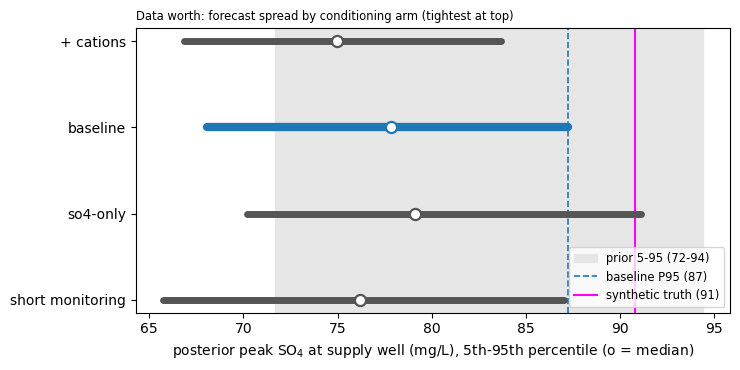

In [15]:
order = arm_order[::-1]   # tightest at the top of the axis
fig, ax = plt.subplots(figsize=(7.5, 0.55 * len(order) + 1.6))

# prior band as a faint reference spanning the whole axis background
ax.axvspan(prior_peak.quantile(0.05), prior_peak.quantile(0.95), color="0.9",
           zorder=0, label=f"prior 5-95 ({prior_peak.quantile(0.05):.0f}-{prior_peak.quantile(0.95):.0f})")

for k, name in enumerate(order):
    r = dw.loc[name]
    color = "#1f77b4" if name == "baseline" else "#555555"
    lw = 6 if name == "baseline" else 5
    ax.plot([r.p05, r.p95], [k, k], color=color, lw=lw, solid_capstyle="round", zorder=2)
    ax.plot(r["median"], k, "o", color="white", mec=color, ms=8, mew=1.6, zorder=3)

ax.axvline(dw.loc["baseline", "p95"], color="#1f77b4", ls="--", lw=1.2, zorder=1,
           label=f"baseline P95 ({dw.loc['baseline','p95']:.0f})")
ax.axvline(truth_fc, color="fuchsia", lw=1.5, zorder=1, label=f"synthetic truth ({truth_fc:.0f})")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_xlabel("posterior peak SO$_4$ at supply well (mg/L), 5th-95th percentile (o = median)")
ax.set_title("Data worth: forecast spread by conditioning arm (tightest at top)",
             loc="left", fontsize="small")
ax.legend(fontsize="small", loc="lower right")
fig.tight_layout()

## The honest reading

The worth of an arm is decision-first: did it tighten the forecast (narrower 5&ndash;95 band) and pull down the P95? We read that **off the numbers**, not off a story we wanted to tell &mdash; the direction of every claim below is computed from the table:

In [16]:
base = dw.loc["baseline"]

# the cation arm: the headline. worth = change in spread and P95 vs baseline
cat = dw.loc["+ cations"]
dwidth = cat.width - base.width
dp95 = cat.p95 - base.p95
cat_verdict = ("worth paying for" if (dwidth < -0.5 or dp95 < -0.5)
               else "not clearly worth it")
print(f"+ cations vs baseline: 5-95 width {base.width:.1f} -> {cat.width:.1f} mg/L "
      f"({'tighter' if dwidth < 0 else 'wider'} by {abs(dwidth):.1f}); "
      f"P95 {base.p95:.1f} -> {cat.p95:.1f} ({'down' if dp95 < 0 else 'up'} {abs(dp95):.1f})")
print(f"  verdict: the held-back cations are {cat_verdict.upper()}\n")

# so4-only: how much of the baseline's worth is sulfate alone vs the other species?
so4 = dw.loc["so4-only"]
print(f"so4-only vs baseline: 5-95 width {so4.width:.1f} vs {base.width:.1f} mg/L "
      f"-- sulfate alone leaves the band {'wider' if so4.width > base.width else 'tighter'}; "
      f"the {'oxidant/buffer/heat species carry real extra worth' if so4.width > base.width + 0.5 else 'extra species add little'}")

# short monitoring: what does the back half of the history window add?
short = dw.loc["short monitoring"]
print(f"short monitoring vs baseline: 5-95 width {short.width:.1f} vs {base.width:.1f} mg/L "
      f"-- cutting monitoring to <=180 d leaves the band {'wider' if short.width > base.width else 'no wider'}; "
      f"the back half of monitoring {'earns its keep' if short.width > base.width + 0.5 else 'adds little to the forecast'}")

+ cations vs baseline: 5-95 width 19.2 -> 16.8 mg/L (tighter by 2.3); P95 87.2 -> 83.7 (down 3.6)
  verdict: the held-back cations are WORTH PAYING FOR

so4-only vs baseline: 5-95 width 21.0 vs 19.2 mg/L -- sulfate alone leaves the band wider; the oxidant/buffer/heat species carry real extra worth
short monitoring vs baseline: 5-95 width 21.3 vs 19.2 mg/L -- cutting monitoring to <=180 d leaves the band wider; the back half of monitoring earns its keep


Read these as a *budget* statement, not a slogan. The chart and table say which analyte and which monitoring effort moved the supply-well sulfate forecast and which did not &mdash; the direction taken straight from the conditioned ensembles. A row visibly tighter than the baseline, especially one that pulls the P95 down, is worth the lab budget; a row indistinguishable from the baseline is effort the forecast never feels.

A second view drives the headline home: overlay the supply-well sulfate **breakthrough ensemble** for the baseline against the cation arm over the supply period. If the cations are worth it, the cation ribbon is visibly narrower in the supply window &mdash; the same kind of picture the optimization notebook leans on, but here it is the *measurement* doing the tightening, not the decision. We rebuild each arm's posterior ensemble from its run directory to draw the ribbons:

dsi.obs.


dsi.obs.


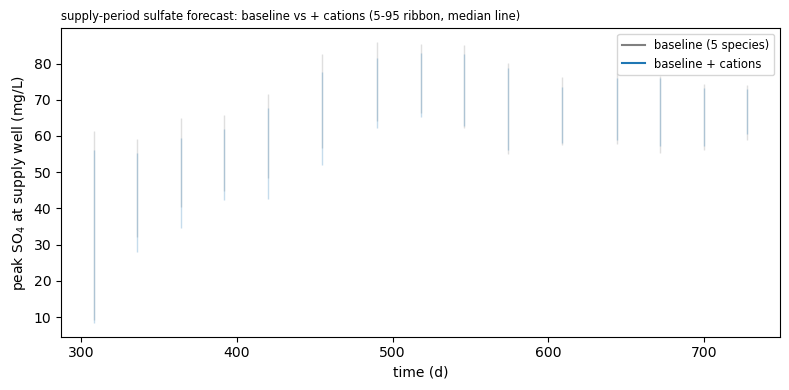

In [17]:
def supply_ribbon(name):
    """Per-time supply-well SO4 (mg/L), max over screens, for one arm's posterior ensemble."""
    dtd = Path(f"dw_{name}")
    rpst = pyemu.Pst(str(dtd / "dsi.pst"))
    obsen = rpst.ies.obsen
    last_it = max(i for i in range(4) if (dtd / f"dsi.{i}.obs.jcb").exists())
    oe_post = obsen.loc[last_it]
    sup = conc.loc[conc.obsid.isin(FORECAST_SCREENS) & (conc.variable == "so4")
                   & (conc.time >= SUPPLY_START) & (conc.time <= SUPPLY_END)]
    times = sorted(sup.time.dropna().unique())
    lo, md_, hi = [], [], []
    for t in times:
        cols = [c for c in sup.loc[sup.time == t].obsnme if c in oe_post.columns]
        # max over screens at this time, per realisation, then mg/L
        series = oe_post.loc[:, cols].max(axis=1) * 1000.0 * SO4_MW
        lo.append(series.quantile(0.05)); md_.append(series.median()); hi.append(series.quantile(0.95))
    return np.array(times), np.array(lo), np.array(md_), np.array(hi)

fig, ax = plt.subplots(figsize=(8, 4))
for name, color in [("baseline", "0.5"), ("cations", "#1f77b4")]:
    t, lo, md_, hi = supply_ribbon(name)
    label = "baseline (5 species)" if name == "baseline" else "baseline + cations"
    ax.fill_between(t, lo, hi, color=color, alpha=0.25)
    ax.plot(t, md_, color=color, lw=1.5, label=label)
ax.set_xlabel("time (d)")
ax.set_ylabel("peak SO$_4$ at supply well (mg/L)")
ax.set_title("supply-period sulfate forecast: baseline vs + cations (5-95 ribbon, median line)",
             loc="left", fontsize="small")
ax.legend(fontsize="small")
fig.tight_layout()

## Wrap-up

What this notebook bought us:

- It turned the held-back cations from a promise into an **answer**: a ranked, decision-first statement of which analytes and which monitoring effort would have tightened the supply-well sulfate forecast, read straight off the conditioned ensembles &mdash; not asserted.
- It did the whole thing on the emulator. The held-back cations were already simulated by the prior Monte Carlo &mdash; the data worth was a matter of re-slicing columns and re-conditioning in seconds, **with no new full-model runs**. Done conventionally this is days of ~6 min/run compute *per arm*; the emulation dividend is what makes it routine instead of heroic.
- The so4-only and short-monitoring arms answered the budget question from both sides: not only "what should we add?" but "what could we cut?"

And the caveat that earns its keep. This is data worth *against the synthetic truth*: it tells us which measurements would help in a world the model can perfectly represent. In the field, structural error sets a ceiling on what any measurement can constrain, and a cation that looks worthwhile here may carry less (or more) where the model and reality diverge. The method is exactly right; the numbers are a guide for the real campaign, not a guarantee. That gap between synthetic worth and field worth is the lesson the [real-data capstone](../part1_09_real_data_capstone/) takes up directly.